<a href="https://colab.research.google.com/github/odairmarcelopaixao-commits/Analise-de-Dados-GENERATION/blob/main/Fundamentos_de_Ci%C3%AAncia_de_Dados_Generation_22042026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# para trabalhar com coleta de informações
# 1 - entrada manaual - usuario informa dados
# 2 - rapagem de dados - ou web scraping - entra em um site e coleta seus dados
# 3 - importação/automação - sensores, apis ...

# vamos usar web scraping para coletar dados de noticias
import requests
import pandas as pd
# para puxar uma função específica de ua biblioteca,
 # não precisamos dela toda, from BIBLIOTECA import FUNÇÃO
from datetime import datetime

# temos que importar um biblioteca de web scraping
from bs4 import BeautifulSoup

In [11]:
import requests
import pandas as pd
from datetime import datetime
from bs4 import BeautifulSoup

# vamos criar a função para coletar os dados do site alvo
def coletar_noticias_g1():
    url = 'https://www.g1.globo.com/'

    # vamos usar um agente para que o site não bloqueie nossa reuisição
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36'
    }

    # agora vamos condicionar nosso uso
    # try - ecept (if -else)
    # try " = if status.code == 200"
    try:
        resposta = requests.get(url, headers=headers)
        #eu quero verificar se deu tudo certo, como se es tivesse usado status code
        resposta.raise_for_status()

        # vou conectar o web scraping para coletar os dados
        #variavel = chama a bibliotec(método que armazena (response.text), atributo de coleta)
        soup = BeautifulSoup(resposta.text, 'html.parser')

        # de onde vamos pegar as informações
        # comando find_all('a', class_='feed_post_link') - encontre tudo
        # A classe 'feed_post_link' pode estar desatualizada. Sites de notícias mudam frequentemente.
        # Você pode precisar inspecionar a página do G1 (botão direito > inspecionar elemento)
        # para encontrar o nome da classe atual para os links de notícias.
        posts = soup.find_all('a', class_='feed-post-link')

        lista_noticias = []

        for i in posts:
            titulo = i.get_text()
            link = i.get('href')
            lista_noticias.append({'Titulo': titulo,
                                   'Link': link,
                                   'Data': datetime.now().strftime("%d/%m/%Y")})

        df_noticias = pd.DataFrame(lista_noticias)

        # dentro do try, para mostrar os dados sempre é legal
        return df_noticias
    except Exception as e:
        print(f'Não consegui ler as noticias: {e}')
        return None

In [12]:
noticias = coletar_noticias_g1()
if noticias is not None:
  display(noticias.head(10))

Não consegui ler as noticias: HTTPSConnectionPool(host='www.g1.globo.com', port=443): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7fe4f0d1a0c0>: Failed to establish a new connection: [Errno 111] Connection refused'))


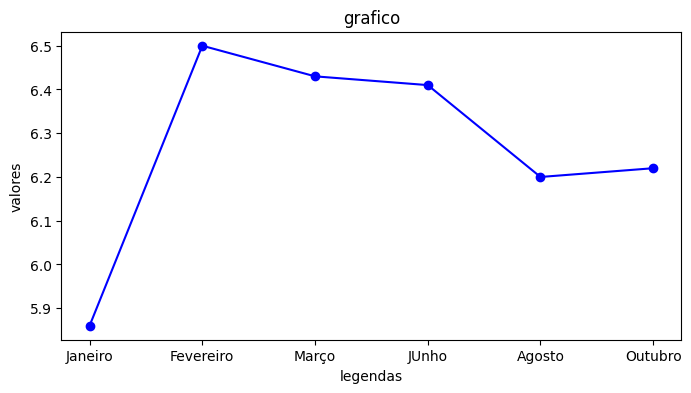

In [15]:
# vamos criar um grafico com o valor médio da gasolina mÊs a mês em 2025

# para fazer um gráfico precisamos de, pelo menos, dois eixos
x_mes = ['Janeiro', 'Fevereiro', 'Março', 'JUnho', 'Agosto', 'Outubro']
# precisamos de um eixo de legenda e um eixo de valor, pelo menos
y_preco = [5.86, 6.50, 6.43, 6.41, 6.20, 6.22]

# a bilioteca que gera graficos é matplotlib ou ploty

# com matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4)) # dimensionamento da imagem - OPCIONAL
# para gerar o gráfico
# plt.plot(eixo x, eixo y, maker='0', color='COR EM INGLES')
plt.plot(x_mes, y_preco, marker='o', color='blue')
# se quiser título
plt.title('grafico')
# nomear os eixos
plt.xlabel('legendas')
plt.ylabel('valores')
# para mostrar
plt.show()